## <span style="color:red">  Numerical exercises 1</span>

### Exercise 01.1
Stima di $\langle r \rangle$ + deviazione standard e rappresentazione grafica. Si calcola $\langle r \rangle$ come media cumulativa:
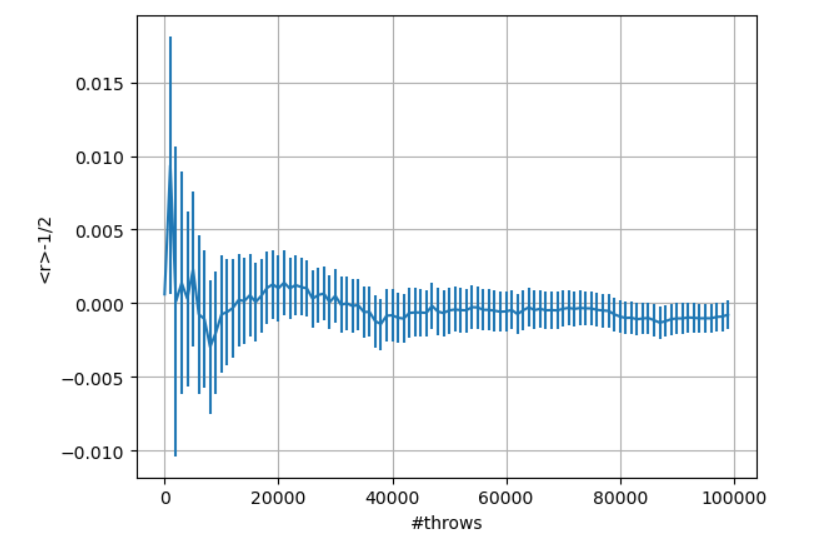

All'aumentare del numero di *throws*, il valore di $\langle r \rangle$ tende al valore atteso, $0.5$, mostrando la convergenza della stima verso il corretto valore teorico.


Successivamente, $r$ viene sostituito con $(r-1/2)^2$, ottenendo il seguente grafico, che oscilla attorno a $1/12$ mantenendo lo stesso andamento:
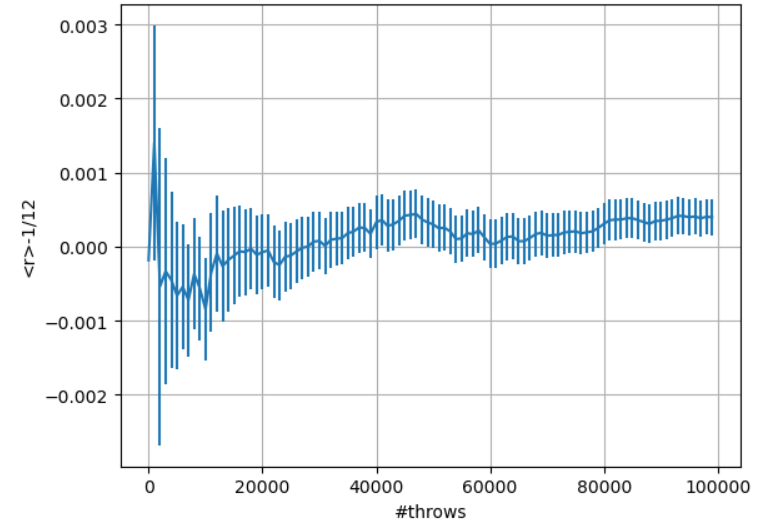

Nella terza parte viene effettuata una stima della statistica $\chi^2$, confrontando il numero di eventi osservati in ciascuno dei $M$ sottointervalli con il valore atteso per una distribuzione uniforme. Il risultato è il seguente grafico:
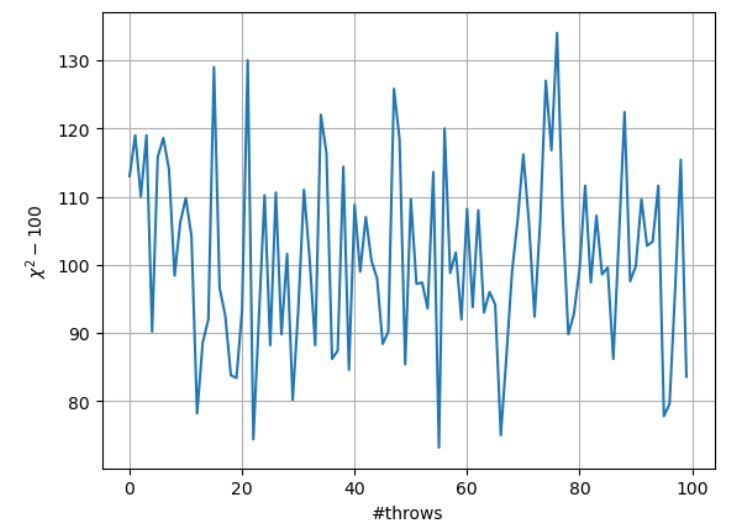
Si osserva un'oscillazione attorno a $100$, che rappresenta il valore atteso: i valori si collocano principalmente tra $85$ e $115$, con alcuni picchi più bassi (inferiori a $80$) e altri più alti (superiori a $130$).

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

def error(AV,AV2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((AV2[n] - AV[n]**2)/n)

M=100000              # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block
np.random.seed(1)     # Fixing random seed for reproducibility
r = np.random.rand(M) # U[0,1) uniform distribution
x = np.arange(N)      # [0,1,2,...,N-1]
ave = np.zeros(N)
av2 = np.zeros(N)
sum_prog = np.zeros(N)
su2_prog = np.zeros(N)
err_prog = np.zeros(N)

for i in range(N):
    sum1 = 0
    for j in range(L):
        k = j+i*L
        sum1 += (r[k]-0.5)**2
    ave[i] = sum1/L     # r_i 
    av2[i] = (ave[i])**2 # (r_i)^2 

for i in range(N):
    for j in range(i+1):
        sum_prog[i] += ave[j] # SUM_{j=0,i} r_j
        su2_prog[i] += av2[j] # SUM_{j=0,i} (r_j)^2
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    err_prog[i] = error(sum_prog,su2_prog,i) # Statistical uncertainty
    
x*=L # Number of throws = block * (Number of throws in each block)
plt.errorbar(x,sum_prog-1/12,yerr=err_prog)
plt.xlabel('#throws')
plt.ylabel('<r>-1/12')
plt.grid(True)
plt.show()

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

def error(AV,AV2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((AV2[n] - AV[n]**2)/n)

T = 100000            # Total number of throws
N = 100               # Number of blocks
M = 100               # Number of subintervals
n = int(T/N)          # Number of throws in each block, please use for M a multiple of N
np.random.seed(1)     # Fixing random seed for reproducibility
r = np.random.rand(T) # U[0,1) uniform distribution
x = np.arange(N)      # [0,1,2,...,N-1]
E = n/M               # Expected value
chi = np.zeros(N)     
#ch2 = np.zeros(N)
#chi_prog = np.zeros(N)
#ch2_prog = np.zeros(N)
#err_prog = np.zeros(N)

for i in range(N):
    sum1 = 0
    O = np.zeros(M)   # Observed value in each subinterval
    
    for j in range(n):
        k = j+i*n
        O[int(r[k]*M)] += 1

    # chi^2 for block i
    for m in range(M):
        sum1 += (O[m]-E)**2/E
        
    chi[i] = sum1     # X_i 
    #ch2[i] = chi[i]**2    # X^2_i

#for i in range(N):
 #   for j in range(i+1):
  #      chi_prog[i] += chi[j] # SUM_{j=0,i} X_j
   #     ch2_prog[i] += ch2[j] # SUM_{j=0,i} (X_j)^2
    #chi_prog[i]/=(i+1) # Cumulative average
    #ch2_prog[i]/=(i+1) # Cumulative square average
    #err_prog[i] = error(chi_prog,ch2_prog,i) # Statistical uncertainty
    
#x*=N # Number of throws = block * (Number of throws in each block)
plt.errorbar(x,chi)
plt.xlabel('#throws')
plt.ylabel('$\chi^2-100$')
plt.grid(True)
plt.show()

### Exercise 01.2
Sono stati creati tre istogrammi, uno per ciascun tipo di distribuzione, per quattro diversi valori di $N$: $1$, $2$, $10$ e $100$.
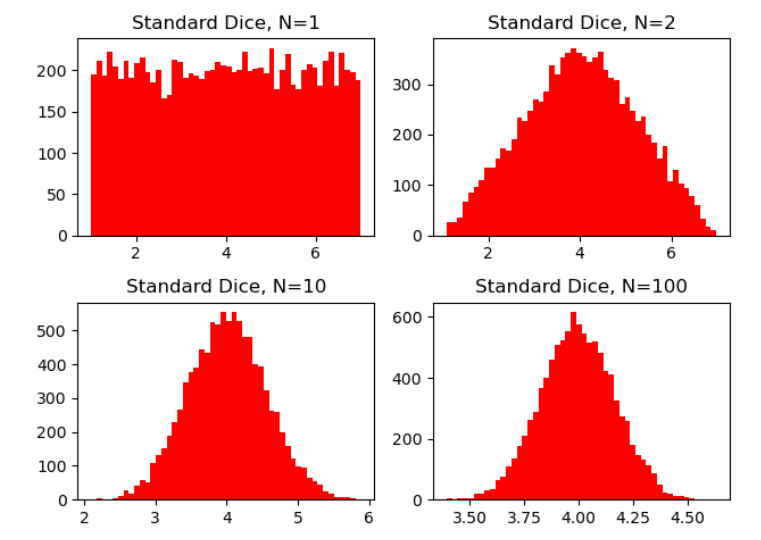
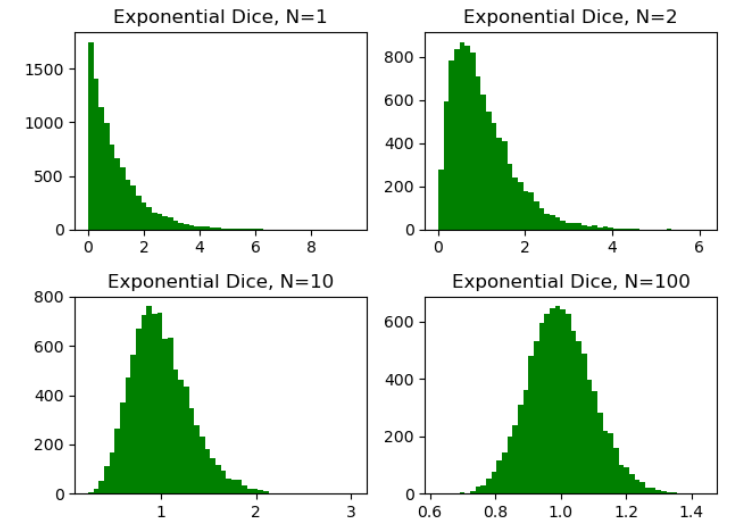
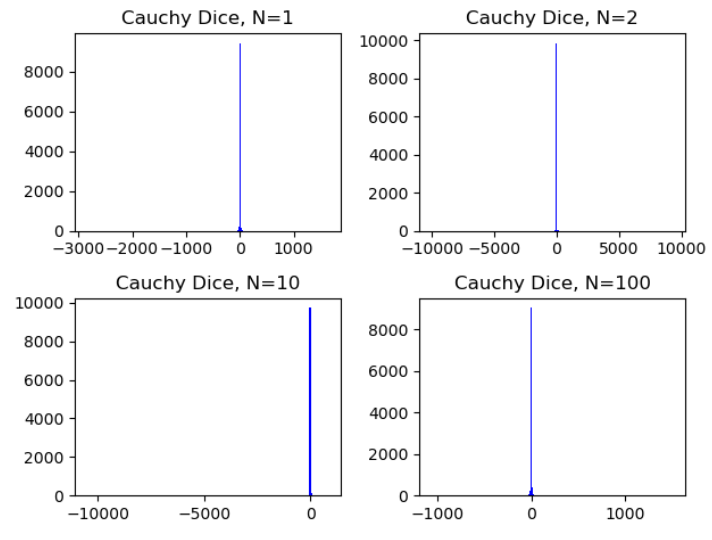

Nel primo caso, relativo a un dado standard, si può osservare che per $N=1$ la distribuzione è uniforme tra $1$ e $6$, mentre all'aumentare di $N$ tende progressivamente a una distribuzione gaussiana. Per $N=100$ l'istogramma diventa stretto e simmetrico, confermando il teorema del limite centrale: aumentando $N$, $S_N$ tende a una distribuzione gaussiana.

Lo stesso comportamento si osserva per il dado con distribuzione esponenziale. Per $N=1$ la distribuzione è chiaramente esponenziale, ma con l'aumento di $N$ perde progressivamente la sua pendenza, si smussa e diventa infine completamente gaussiana.

Nel caso della distribuzione di Cauchy, invece, il teorema del limite centrale non è soddisfatto. La distribuzione mantiene la stessa forma indipendentemente dal valore di $N$ e non converge a una gaussiana. I valori rimangono concentrati in prossimità dello zero, mentre quelli più estremi (molto grandi o molto piccoli) fanno espandere notevolmente l'asse delle ascisse, motivo per cui l'istogramma appare quasi come una linea retta.


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

# standard dice
stand = np.loadtxt("S_standard.dat")
S1 = stand[stand[:,0] == 1][:,1]
S2 = stand[stand[:,0] == 2][:,1]
S10 = stand[stand[:,0] == 10][:,1]
S100 = stand[stand[:,0] == 100][:,1]

plt.subplot(2,2,1)
plt.hist(S1, bins = 50, color='red')
plt.title('Standard Dice, N=1')

plt.subplot(2,2,2)
plt.hist(S2, bins = 50, color='red')
plt.title('Standard Dice, N=2')

plt.subplot(2,2,3)
plt.hist(S10, bins = 50, color='red')
plt.title('Standard Dice, N=10')

plt.subplot(2,2,4)
plt.hist(S100, bins = 50, color='red')
plt.title('Standard Dice, N=100')

plt.tight_layout()
plt.show()

# exponential dice
exp = np.loadtxt("S_exponential.dat")
S1 = exp[exp[:,0] == 1][:,1]
S2 = exp[exp[:,0] == 2][:,1]
S10 = exp[exp[:,0] == 10][:,1]
S100 = exp[exp[:,0] == 100][:,1]

plt.subplot(2,2,1)
plt.hist(S1, bins = 50, color='green')
plt.title('Exponential Dice, N=1')

plt.subplot(2,2,2)
plt.hist(S2, bins = 50, color='green')
plt.title('Exponential Dice, N=2')

plt.subplot(2,2,3)
plt.hist(S10, bins = 50, color='green')
plt.title('Exponential Dice, N=10')

plt.subplot(2,2,4)
plt.hist(S100, bins = 50, color='green')
plt.title('Exponential Dice, N=100')

plt.tight_layout()
plt.show()

# Cauchy dice
cauchy = np.loadtxt("S_cauchy.dat")
S1 = cauchy[cauchy[:,0] == 1][:,1]
S2 = cauchy[cauchy[:,0] == 2][:,1]
S10 = cauchy[cauchy[:,0] == 10][:,1]
S100 = cauchy[cauchy[:,0] == 100][:,1]

plt.subplot(2,2,1)
plt.hist(S1, bins = 200, color='blue')
plt.title('Cauchy Dice, N=1')

plt.subplot(2,2,2)
plt.hist(S2, bins = 200, color='blue')
plt.title('Cauchy Dice, N=2')

plt.subplot(2,2,3)
plt.hist(S10, bins = 200, color='blue')
plt.title('Cauchy Dice, N=10')

plt.subplot(2,2,4)
plt.hist(S100, bins = 200, color='blue')
plt.title('Cauchy Dice, N=100')

plt.tight_layout()
plt.show()

### Exercise 01.3
In questo esercizio viene effettuata una stima di $\pi$ mediante l'esperimento di Buffon, nel quale un ago di lunghezza $L$ viene lanciato casualmente su un piano con linee parallele distanti tra loro di una distanza $d$. A partire dal numero di intersezioni osservate, si ottiene il seguente grafico della stima:
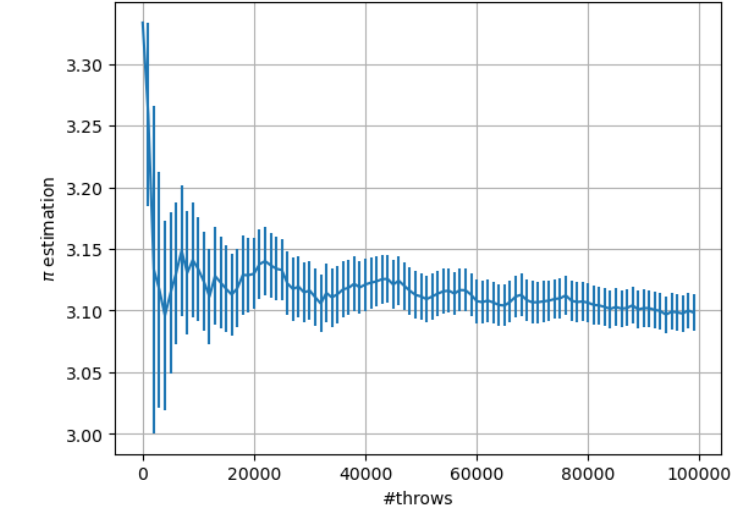
Si può osservare che, all'aumentare del numero di blocchi, il valore stimato di $\pi$ si avvicina progressivamente al valore atteso e le fluttuazioni diminuiscono. Ciò rappresenta il fatto che, quando $N$ tende all'infinito, la stima diventa sempre più precisa e converge al valore di $\pi \approx 3.14$, in accordo con l'esperimento di Buffon.

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

def error(AV,AV2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((AV2[n] - AV[n]**2)/n)

M=100000              # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block
np.random.seed(1)     # Fixing random seed for reproducibility
x = np.arange(N)      # [0,1,2,...,N-1]
pi = np.zeros(N)
pi2 = np.zeros(N)
sum_prog = np.zeros(N)
su2_prog = np.zeros(N)
err_prog = np.zeros(N)

leng = 0.5                      # Needle´s lenght 
d = 1                           # distance between lines (L<d)

for i in range(N):
    y = np.random.uniform(0,d/2, L) # random needle´s position L times 
    # to generate theta, generate a random vector (u,v) and calculate the sin
    u = np.random.uniform(-1,1, L)
    v = np.random.uniform(-1,1, L)
    sin = np.abs(v)/np.sqrt(u**2+v**2)
    
    hit = (leng/2*sin >= y)
    N_hit = np.sum(hit)

    #pi estimation
    pi[i] = 2*leng*L /(N_hit*d)
    pi2[i] = pi[i]**2

# data blocking
for i in range(N):
    for j in range(i+1):
        sum_prog[i] += pi[j] # SUM_{j=0,i} r_j
        su2_prog[i] += pi2[j] # SUM_{j=0,i} (r_j)^2
    sum_prog[i]/=(i+1) # Cumulative average
    su2_prog[i]/=(i+1) # Cumulative square average
    err_prog[i] = error(sum_prog,su2_prog,i) # Statistical uncertainty
        
x*=L
plt.errorbar(x,sum_prog,yerr=err_prog)
plt.xlabel('#throws')
plt.ylabel('$\pi$ estimation')
plt.grid(True)
plt.show()